# SI - Three-mode PCLA

This notebook regenerates the measured panels of the three-laser PCLA supplementary figure: input tomography, three-output convergence, pairwise interferograms, and the chip photograph. The compact NPZ contains only the raw traces and 100-point lock-in histories used in the plot; unused acquisition objects and smoothed traces were removed.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the reproduction repository.")


ROOT = find_repository_root()
PNG_DIR = ROOT / "figures" / "png"
SVG_DIR = ROOT / "figures" / "svg"
PNG_DIR.mkdir(parents=True, exist_ok=True)
SVG_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    """Save matching raster and vector copies of a figure."""
    fig.savefig(PNG_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(SVG_DIR / f"{filename}.svg", bbox_inches="tight")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Nimbus Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "axes.grid": False,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D


## Load the reduced measurement bundle

In [2]:
data = np.load(ROOT / "data" / "si_3pcla" / "three_pcla_measurements.npz")
chip_photo = plt.imread(ROOT / "data" / "si_3pcla" / "chip_photo.jpg")

tomography = [data[f"tomography_{name}"] for name in ("laser1", "laser2", "laser3", "total")]
lockin_histories = [data[f"lockin_output{index}"] for index in (1, 2, 3)]
print("Interferogram samples per state:", len(data["contrast_12_initial_signal"]))
print("Optimization iterations:", len(lockin_histories[0]))

Interferogram samples per state: 100000
Optimization iterations: 100


## Plot the complete SI figure

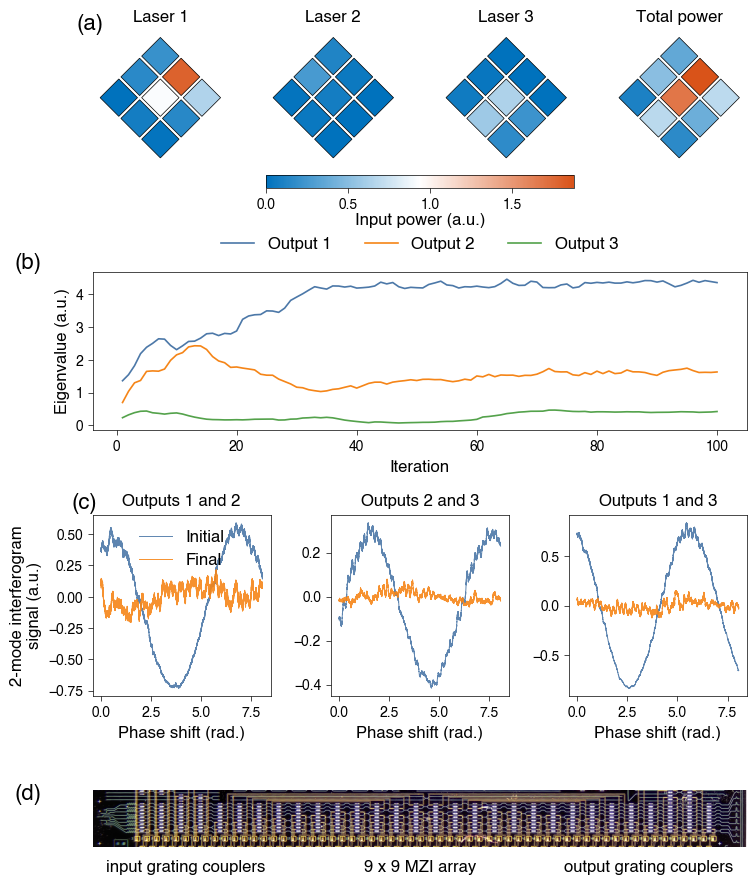

In [3]:
VOLTS2RAD = 0.32209  # rad/V^2, calibrated from the initial 1-2 interferogram
PORT_LAYOUT = np.array([[0, 1, 5], [2, 3, 7], [4, 6, 8]])


def plot_tomography(axis, values, title, cmap, norm):
    rotation = Affine2D().rotate_deg(45)
    for row in range(3):
        for column in range(3):
            x, y = column - 1, 1 - row
            value = values[PORT_LAYOUT[row, column]]
            axis.add_patch(Rectangle(
                (x - 0.45, y - 0.45), 0.9, 0.9,
                facecolor=cmap(norm(value)), edgecolor="black", linewidth=0.5,
                transform=rotation + axis.transData,
            ))
    axis.set(aspect="equal", xlim=(-2.3, 2.3), ylim=(-2.3, 2.3), title=title)
    axis.axis("off")


def centered_interferogram(pair, state, stride=20):
    voltage = data[f"contrast_{pair}_{state}_voltage"]
    signal = data[f"contrast_{pair}_{state}_signal"]
    phase = voltage**2 * VOLTS2RAD
    return phase[::stride], (signal - signal.mean())[::stride]


fig = plt.figure(figsize=(7.56, 9.28))
outer = fig.add_gridspec(4, 1, height_ratios=(1.05, 1.0, 1.15, 0.48), hspace=0.58)
tomography_grid = outer[0].subgridspec(2, 4, height_ratios=(1.0, 0.08), hspace=0.02, wspace=0.28)
tomography_axes = [fig.add_subplot(tomography_grid[0, index]) for index in range(4)]
colorbar_axis = fig.add_subplot(tomography_grid[1, 1:3])

colors = LinearSegmentedColormap.from_list("input_power", ["#0072BD", "white", "#D95319"])
normalization = Normalize(0, max(np.max(vector) for vector in tomography))
for axis, vector, title in zip(
    tomography_axes, tomography, ("Laser 1", "Laser 2", "Laser 3", "Total power")
):
    plot_tomography(axis, vector, title, colors, normalization)
colorbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=normalization, cmap=colors),
    cax=colorbar_axis, orientation="horizontal",
)
colorbar.set_label("Input power (a.u.)", labelpad=1)

ax_convergence = fig.add_subplot(outer[1])
for history, label, color in zip(
    lockin_histories,
    ("Output 1", "Output 2", "Output 3"),
    ("#4c78a8", "#f58518", "#54a24b"),
):
    ax_convergence.plot(np.arange(1, len(history) + 1), history, color=color, linewidth=1.2, label=label)
ax_convergence.set(xlabel="Iteration", ylabel="Eigenvalue (a.u.)")
ax_convergence.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.03))

interferogram_grid = outer[2].subgridspec(1, 3, wspace=0.34)
interferogram_axes = [fig.add_subplot(interferogram_grid[0, index]) for index in range(3)]
for axis, pair, title in zip(
    interferogram_axes,
    ("12", "23", "13"),
    ("Outputs 1 and 2", "Outputs 2 and 3", "Outputs 1 and 3"),
):
    for state, label, color in (("initial", "Initial", "#4c78a8"), ("final", "Final", "#f58518")):
        phase, signal = centered_interferogram(pair, state)
        axis.plot(phase, signal, color=color, linewidth=0.7, alpha=0.9, label=label)
    axis.set(title=title, xlabel="Phase shift (rad.)")
interferogram_axes[0].set_ylabel("2-mode interferogram\nsignal (a.u.)")
interferogram_axes[0].legend()

ax_chip = fig.add_subplot(outer[3])
ax_chip.imshow(chip_photo)
ax_chip.axis("off")
ax_chip.text(0.02, -0.22, "input grating couplers", transform=ax_chip.transAxes, ha="left", va="top")
ax_chip.text(0.50, -0.22, "9 x 9 MZI array", transform=ax_chip.transAxes, ha="center", va="top")
ax_chip.text(0.98, -0.22, "output grating couplers", transform=ax_chip.transAxes, ha="right", va="top")

for label, axis in zip("abcd", [tomography_axes[0], ax_convergence, interferogram_axes[0], ax_chip]):
    axis.text(-0.12, 1.12, f"({label})", transform=axis.transAxes, fontsize=16, ha="left", va="top")

fig.subplots_adjust(left=0.12, right=0.985, bottom=0.07, top=0.97)
save_figure(fig, "si_3pcla")
plt.show()